# Revisión modelo metabólico Yeast9

In [1]:
import cobra
from cobra.io import read_sbml_model
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt

In [2]:
# Cargamos el modelo metabólico:
model_original_o2 = read_sbml_model("yeast-GEM.xml")
model_original_sin_o2 = read_sbml_model("yeast-GEM.xml")
model_modificado = read_sbml_model("yeast-GEM.xml")

In [3]:
# Imprimir información básica del modelo
print("Reacciones:", len(model_original_o2.reactions))
print("Metabolitos:", len(model_original_o2.metabolites))
print("Genes:", len(model_original_o2.genes))

Reacciones: 4131
Metabolitos: 2806
Genes: 1161


In [4]:
# Función objetivo del FBA
print(model_original_o2.objective)

with model_original_o2:
    model_original_o2.optimize()
    print("Flujo óptimo (FBA):", model_original_o2.objective.value)
    pfba_solution = cobra.flux_analysis.pfba(model_original_o2)
    print(f"Flujos de reacción (pFBA): {pfba_solution.objective_value}")

Maximize
1.0*r_2111 - 1.0*r_2111_reverse_58b69
Flujo óptimo (FBA): 0.08584396972646902
Flujos de reacción (pFBA): 100.06167152723609


In [5]:
print(f"Lower bound de fructosa: {model_original_o2.exchanges.get_by_id('r_1709').lower_bound}")

Lower bound de fructosa: 0.0


In [6]:
print(model_original_o2.objective)

with model_original_o2:
    model_original_o2.exchanges.get_by_id('r_1709').lower_bound = -1.0
    print(f"Lower bound de fructosa: {model_original_o2.exchanges.get_by_id('r_1709').lower_bound}")
    model_original_o2.optimize()
    print("Flujo óptimo (FBA):", model_original_o2.objective.value)
    pfba_solution = cobra.flux_analysis.pfba(model_original_o2)
    print(f"Flujos de reacción (pFBA): {pfba_solution.objective_value}")

Maximize
1.0*r_2111 - 1.0*r_2111_reverse_58b69
Lower bound de fructosa: -1.0
Flujo óptimo (FBA): 0.17493742836499762
Flujos de reacción (pFBA): 194.36589388269255


Aumenta flujo óptimo al abrir el lower bound de fructosa a -1.0

## Modificación Yeast9 para condiciones anaeróbicas

In [7]:
from modificacion_yeast9v2 import modify_yeast9_change2_only

### Modelo original anaeróbico

In [8]:
model_original_anaerobic = modify_yeast9_change2_only(model_original_sin_o2)

Removed from r_4598: ['s_3714', 's_1198', 's_1203', 's_1207', 's_1212', 's_0529']
Not found: []


In [9]:
# =========================
# VERIFICACIÓN MODIFICACIONES YEAST9
# =========================

print("--- Verificación Biomass r_4598 ---")

rxn = model_original_anaerobic.reactions.get_by_id("r_4598")

mets_check = [
    "s_3714[c]",
    "s_1198[c]",
    "s_1203[c]",
    "s_1207[c]",
    "s_1212[c]",
    "s_0529[c]",
]

for mid in mets_check:
    try:
        met = model_original_anaerobic.metabolites.get_by_id(mid)
        coeff = rxn.metabolites.get(met, 0)
        print(f"{mid} → coeficiente en r_4598: {coeff}")
    except KeyError:
        print(f"{mid} → metabolito no existe en el modelo")

print("\n--- Verificación límites de reacciones ---")

rxn_0713 = model_original_anaerobic.reactions.get_by_id("r_0713")
print("r_0713 lower bound:", rxn_0713.lower_bound)

rxn_0714 = model_original_anaerobic.reactions.get_by_id("r_0714")
print("r_0714 lower bound:", rxn_0714.lower_bound)

rxn_0487 = model_original_anaerobic.reactions.get_by_id("r_0487")
print("r_0487 upper bound:", rxn_0487.upper_bound)

--- Verificación Biomass r_4598 ---
s_3714[c] → metabolito no existe en el modelo
s_1198[c] → metabolito no existe en el modelo
s_1203[c] → metabolito no existe en el modelo
s_1207[c] → metabolito no existe en el modelo
s_1212[c] → metabolito no existe en el modelo
s_0529[c] → metabolito no existe en el modelo

--- Verificación límites de reacciones ---
r_0713 lower bound: -1000.0
r_0714 lower bound: -1000.0
r_0487 upper bound: 1000.0


### Modelo medio enológico anaeróbico

In [10]:
model_modificado_anaerobic = modify_yeast9_change2_only(model_modificado)

Removed from r_4598: ['s_3714', 's_1198', 's_1203', 's_1207', 's_1212', 's_0529']
Not found: []


In [11]:
# =========================
# VERIFICACIÓN MODIFICACIONES YEAST9
# =========================

print("--- Verificación Biomass r_4598 ---")

rxn = model_modificado_anaerobic.reactions.get_by_id("r_4598")

mets_check = [
    "s_3714[c]",
    "s_1198[c]",
    "s_1203[c]",
    "s_1207[c]",
    "s_1212[c]",
    "s_0529[c]",
]

for mid in mets_check:
    try:
        met = model_modificado_anaerobic.metabolites.get_by_id(mid)
        coeff = rxn.metabolites.get(met, 0)
        print(f"{mid} → coeficiente en r_4598: {coeff}")
    except KeyError:
        print(f"{mid} → metabolito no existe en el modelo")

print("\n--- Verificación límites de reacciones ---")

rxn_0713 = model_modificado_anaerobic.reactions.get_by_id("r_0713")
print("r_0713 lower bound:", rxn_0713.lower_bound)

rxn_0714 = model_modificado_anaerobic.reactions.get_by_id("r_0714")
print("r_0714 lower bound:", rxn_0714.lower_bound)

rxn_0487 = model_modificado_anaerobic.reactions.get_by_id("r_0487")
print("r_0487 upper bound:", rxn_0487.upper_bound)

--- Verificación Biomass r_4598 ---
s_3714[c] → metabolito no existe en el modelo
s_1198[c] → metabolito no existe en el modelo
s_1203[c] → metabolito no existe en el modelo
s_1207[c] → metabolito no existe en el modelo
s_1212[c] → metabolito no existe en el modelo
s_0529[c] → metabolito no existe en el modelo

--- Verificación límites de reacciones ---
r_0713 lower bound: -1000.0
r_0714 lower bound: -1000.0
r_0487 upper bound: 1000.0


## Modelo original:

In [12]:
model_original_o2.reactions.get_by_id("r_2111")

Reaction identifier,r_2111
Name,growth
Memory address,0x150a4dbd330
Stoichiometry,s_0450 --> biomass -->
GPR,
Lower bound,0.0
Upper bound,1000.0


In [13]:
# Límites superiores de importación de nutrientes
reacciones_medio = model_original_o2.medium

In [14]:
for rxn_id, limit in reacciones_medio.items():
   name = model_original_o2.reactions.get_by_id(rxn_id).name
   print(f"{rxn_id}: {name} (límite: {limit})")

r_1654: ammonium exchange (límite: 1000.0)
r_1714: D-glucose exchange (límite: 1.0)
r_1832: H+ exchange (límite: 1000.0)
r_1861: iron(2+) exchange (límite: 1000.0)
r_1992: oxygen exchange (límite: 1000.0)
r_2005: phosphate exchange (límite: 1000.0)
r_2020: potassium exchange (límite: 1000.0)
r_2049: sodium exchange (límite: 1000.0)
r_2060: sulphate exchange (límite: 1000.0)
r_2100: water exchange (límite: 1000.0)
r_4593: chloride exchange (límite: 1000.0)
r_4594: Cu2(+) exchange (límite: 1000.0)
r_4595: Mn(2+) exchange (límite: 1000.0)
r_4596: Zn(2+) exchange (límite: 1000.0)
r_4597: Mg(2+) exchange (límite: 1000.0)
r_4600: Ca(2+) exchange (límite: 1000.0)


In [15]:
len(model_original_o2.exchanges)

271

In [16]:
print(f"Lower bound de fructosa: {model_original_o2.exchanges.get_by_id('r_1709').lower_bound}")


Lower bound de fructosa: 0.0


In [17]:
contador_exportaciones = 0
contador_importaciones = 0
for rxn in model_original_o2.exchanges:
    if rxn.lower_bound < 0:  # Solo reacciones de importación
        contador_importaciones += 1
        print(f"{rxn.id}: {rxn.name} (límite: {rxn.lower_bound})")
    if rxn.upper_bound > 0:  # Solo reacciones de exportación
        contador_exportaciones += 1
    else:
        print(f"REACCIÓN EXPORTACIÓN {rxn.id}: {rxn.name} (límite: {rxn.upper_bound})")
        
print(f"Total de reacciones de importación: {contador_importaciones}")
print(f"Total de reacciones de exportación: {contador_exportaciones}")

r_1654: ammonium exchange (límite: -1000.0)
REACCIÓN EXPORTACIÓN r_1663: bicarbonate exchange (límite: 0.0)
r_1714: D-glucose exchange (límite: -1.0)
r_1832: H+ exchange (límite: -1000.0)
r_1861: iron(2+) exchange (límite: -1000.0)
r_1992: oxygen exchange (límite: -1000.0)
r_2005: phosphate exchange (límite: -1000.0)
r_2020: potassium exchange (límite: -1000.0)
r_2049: sodium exchange (límite: -1000.0)
r_2060: sulphate exchange (límite: -1000.0)
r_2100: water exchange (límite: -1000.0)
r_4593: chloride exchange (límite: -1000.0)
r_4594: Cu2(+) exchange (límite: -1000.0)
r_4595: Mn(2+) exchange (límite: -1000.0)
r_4596: Zn(2+) exchange (límite: -1000.0)
r_4597: Mg(2+) exchange (límite: -1000.0)
r_4600: Ca(2+) exchange (límite: -1000.0)
Total de reacciones de importación: 16
Total de reacciones de exportación: 270


* Hay 16 reacciones de intercambio que tienen lower bounds abiertos (medio). 
* La única reacción de intercambio que tiene el upper bound cerrado es r_1663 (bicarbonate exchange). 

In [18]:
for rxn in model_original_o2.exchanges:
    print(f"{rxn.id}: {rxn.name}")

r_1542: (1->3)-beta-D-glucan exchange
r_1545: (R)-carnitine exchange
r_1546: (R)-lactate exchange
r_1547: (R)-mevalonate exchange
r_1548: (R)-pantothenate exchange
r_1549: (R,R)-2,3-butanediol exchange
r_1550: (S)-3-methyl-2-oxopentanoate exchange
r_1551: (S)-lactate exchange
r_1552: (S)-malate exchange
r_1553: 1-(sn-glycero-3-phospho)-1D-myo-inositol exchange
r_1554: 1-acylglycerophosphocholine exchange
r_1563: 2'-deoxyadenosine exchange
r_1564: 2'-deoxyguanosine exchange
r_1565: 2'-deoxyinosine exchange
r_1566: 2'-deoxyuridine exchange
r_1572: 2-isopropylmalate exchange
r_1577: 2-methylbutanal exchange
r_1580: 2-methylbutanol exchange
r_1581: 2-methylbutyl acetate exchange
r_1586: 2-oxoglutarate exchange
r_1589: 2-phenylethanol exchange
r_1598: 3-methylbutanal exchange
r_1604: 4-aminobenzoate exchange
r_1621: 5-aminolevulinate exchange
r_1625: 5-formyltetrahydrofolic acid exchange
r_1627: 7,8-diaminononanoate exchange
r_1629: 8-amino-7-oxononanoate exchange
r_1630: 9H-xanthine exchan

In [11]:
res1 = cobra.flux_analysis.flux_variability_analysis(model_original_o2, model_original_o2.exchanges, fraction_of_optimum=0.9)

In [12]:
print(res1)

        minimum   maximum
r_1542      0.0  0.000000
r_1545      0.0  0.000000
r_1546      0.0  0.174518
r_1547      0.0  0.083836
r_1548      0.0  0.042558
...         ...       ...
r_4737      0.0  0.116112
r_4739      0.0  0.000000
r_4741      0.0  0.077299
r_4743      0.0  0.063647
r_4780      0.0  0.008785

[271 rows x 2 columns]


## Modelo sin O2

In [19]:
model_original_anaerobic.reactions.get_by_id("r_1992").lower_bound = 0 # consumo de oxígeno a 0
results = model_original_anaerobic.optimize()
results_pfba = cobra.flux_analysis.pfba(model_original_anaerobic)
print(f"Flujo óptimo sin O2 (FBA): {results.objective_value}")
print(f"Etanol (FBA): {model_original_anaerobic.exchanges.get_by_id('r_1761').flux}")
print(f"Flujo óptimo sin O2 (pFBA): {results_pfba.objective_value}")
print(f"Etanol (pFBA): {model_original_anaerobic.exchanges.get_by_id('r_1761').flux}")

Flujo óptimo sin O2 (FBA): 0.0
Etanol (FBA): 0.7000000000000001
Flujo óptimo sin O2 (pFBA): 10.849999999999998
Etanol (pFBA): 0.7000000000000001


In [20]:
# Agregando factores anaeróbicos:
with model_original_anaerobic:
    for factores_anaerobicos in ["r_1757","r_1915","r_1994","r_2106","r_2134","r_2137","r_2189"]:
        if factores_anaerobicos in model_original_anaerobic.reactions:
            model_original_anaerobic.reactions.get_by_id(factores_anaerobicos).lower_bound = -1000
            
    model_modificado_anaerobic.exchanges.get_by_id('r_1714').lower_bound = -1.0
    model_modificado_anaerobic.exchanges.get_by_id('r_1709').lower_bound = 0.0
    print(f"Lower bound de glucosa: {model_modificado_anaerobic.exchanges.get_by_id('r_1714').lower_bound}")
    print(f"Lower bound de fructosa: {model_modificado_anaerobic.exchanges.get_by_id('r_1709').lower_bound}")

    # model_original_anaerobic.objective = "r_4598"
    sol_test = model_original_anaerobic.optimize()
    results_pfba_test = cobra.flux_analysis.pfba(model_original_anaerobic)
    print(f"Flujo óptimo sin O2 (FBA): {sol_test.objective_value}")
    print(f"Etanol (FBA): {model_original_anaerobic.exchanges.get_by_id('r_1761').flux}")
    print(f"Flujo óptimo sin O2 (pFBA): {results_pfba_test.objective_value}")
    print(f"Etanol (pFBA): {model_original_anaerobic.exchanges.get_by_id('r_1761').flux}")

Lower bound de glucosa: -1.0
Lower bound de fructosa: 0.0
Flujo óptimo sin O2 (FBA): 0.013650048614975308
Etanol (FBA): 1.6586991796933237
Flujo óptimo sin O2 (pFBA): 31.211083995324667
Etanol (pFBA): 1.6586991796933237


Agregando factores anaeróbicos aumenta el flujo de crecimiento y del etanol

## Medio de cultivo para condiciones enológicas:

<img src="Captura de pantalla 2026-02-24 111018.png" width="500">

In [21]:
medio_enologico = [
    # "r_1714","r_1709",      # CARBONO: D-glucose, D-fructose
    "r_1687","r_1552",      # ÁCIDOS ORGÁNICOS: citrate, (S)-malate
    "r_2005","r_2060",      # SALES/IONES: phosphate, sulphate
    "r_2020","r_2049",      # potassium, sodium 
    "r_4593","r_4600",      # chloride, Ca2+
    "r_4597","r_4595",      # Mg2+, Mn2+
    "r_4596","r_4594",      # Zn2+, Cu2+
    "r_1947","r_1967",      # VITAMINAS: myo-inositol, nicotinate
    "r_1548","r_2067",      # (R)-pantothenate, thiamine(1+)
    "r_2028","r_1671",      # pyridoxine, biotin
    "r_1757","r_2189",      # FACTORES ANAERÓBICOS: ergosterol, oleate
    "r_1654",               # ammonium
    # r_1757","r_1915","r_1994","r_2106","r_2134","r_2137","r_2189
    "r_1915","r_1994",      # OTROS FACTORES ANAERÓBICOS: lanosterol, palmitoleate
    "r_2106","r_2134",      # zymosterol, 14-demethyllanosterol
    "r_2137",               # ergosta-5,7,22,24(28)-tetraen-3beta-ol
    "r_1873","r_1879",      # AMINOÁCIDOS: alanine, arginine
    "r_1881","r_1889",      # aspartate, glutamate
    "r_1891","r_1893",      # glutamine, histidine
    "r_1897","r_1899",      # isoleucine, leucine
    "r_1900","r_1902",      # lysine, methionine
    "r_1903","r_1906",      # phenylalanine, proline
    "r_1911","r_1912",      # threonine, tryptophan
    "r_1913","r_1914",      # tyrosine, valine
    "r_1810",               # glycine
    # EXTRAS PARA QUE FUNCIONE MODELO:
    "r_1832",               # H+
    "r_1861",               # iron(2+)
    "r_2100"                # water
]

In [22]:
# Cerramos todos los lower bounds de las reacciones de exchange
for rxn in model_modificado_anaerobic.exchanges:
    rxn.lower_bound = 0
        
# Revisamos que se hayan cerrado correctamente con el intercambio de amonio:
print(f"Antes {model_modificado_anaerobic.exchanges.get_by_id('r_1654').name} (límite: {model_modificado_anaerobic.exchanges.get_by_id('r_1654').lower_bound})")
for reaction in medio_enologico:
    model_modificado_anaerobic.exchanges.get_by_id(reaction).lower_bound = -1000
print(f"Después {model_modificado_anaerobic.exchanges.get_by_id('r_1654').name} (límite: {model_modificado_anaerobic.exchanges.get_by_id('r_1654').lower_bound})")

# agregamos manualmente glucosa y fructosa
model_modificado_anaerobic.exchanges.get_by_id('r_1714').lower_bound = -1.0
model_modificado_anaerobic.exchanges.get_by_id('r_1709').lower_bound = -1.0
    
# Asegurar anaerobiosis:
model_modificado_anaerobic.reactions.get_by_id("r_1992").lower_bound = 0.0 # consumo de oxígeno a 0

print(f"Lower bound de O_2: {model_modificado_anaerobic.reactions.get_by_id('r_1992').lower_bound}")

    
results_medio = model_modificado_anaerobic.optimize()
results_medio_pfba = cobra.flux_analysis.pfba(model_modificado_anaerobic)

print(f"Flujo óptimo con medio definido (FBA): {results_medio_pfba.objective_value}")
print(f"Etanol (FBA): {model_modificado_anaerobic.exchanges.get_by_id('r_1761').flux}")
print(f"Flujo óptimo con medio definido (pFBA): {results_medio_pfba.objective_value}")
print(f"Etanol (pFBA): {model_modificado_anaerobic.exchanges.get_by_id('r_1761').flux}") 

Antes ammonium exchange (límite: 0)
Después ammonium exchange (límite: -1000)
Lower bound de O_2: 0.0
Flujo óptimo con medio definido (FBA): 67926.18085245625
Etanol (FBA): 0.0
Flujo óptimo con medio definido (pFBA): 67926.18085245625
Etanol (pFBA): 0.0


In [23]:
model_original_o2.reactions.get_by_id("r_4598").name

'cofactor pseudoreaction'

## Simulación con dFBA

In [24]:
i=1
for exchange_reactions in model_original_o2.exchanges:
  print(f"Exchange reactiones n°{i}: {exchange_reactions.id}")
  i+=1
  
print(len(model_original_o2.exchanges))

Exchange reactiones n°1: r_1542
Exchange reactiones n°2: r_1545
Exchange reactiones n°3: r_1546
Exchange reactiones n°4: r_1547
Exchange reactiones n°5: r_1548
Exchange reactiones n°6: r_1549
Exchange reactiones n°7: r_1550
Exchange reactiones n°8: r_1551
Exchange reactiones n°9: r_1552
Exchange reactiones n°10: r_1553
Exchange reactiones n°11: r_1554
Exchange reactiones n°12: r_1563
Exchange reactiones n°13: r_1564
Exchange reactiones n°14: r_1565
Exchange reactiones n°15: r_1566
Exchange reactiones n°16: r_1572
Exchange reactiones n°17: r_1577
Exchange reactiones n°18: r_1580
Exchange reactiones n°19: r_1581
Exchange reactiones n°20: r_1586
Exchange reactiones n°21: r_1589
Exchange reactiones n°22: r_1598
Exchange reactiones n°23: r_1604
Exchange reactiones n°24: r_1621
Exchange reactiones n°25: r_1625
Exchange reactiones n°26: r_1627
Exchange reactiones n°27: r_1629
Exchange reactiones n°28: r_1630
Exchange reactiones n°29: r_1631
Exchange reactiones n°30: r_1634
Exchange reactiones

In [25]:
init = np.zeros(272)
# BUSCAMOS NITRÓGENO, O2, GLUCOSA Y FRUCTUSA
i=1
for exchange_reactions in model_original_o2.exchanges:
    if exchange_reactions.id == "r_1654":
        print(f"Exchange reactiones n°{i}: {exchange_reactions.name}")
    elif exchange_reactions.id == "r_1992": 
        print(f"Exchange reactiones n°{i}: {exchange_reactions.name}")
    elif exchange_reactions.id == "r_1714": 
        print(f"Exchange reactiones n°{i}: {exchange_reactions.name}")
    elif exchange_reactions.id == "r_1709": 
        print(f"Exchange reactiones n°{i}: {exchange_reactions.name}")
    elif exchange_reactions.id == "r_1761":
        print(f"Exchange reactiones n°{i}: {exchange_reactions.name}")
    i+=1

Exchange reactiones n°38: ammonium exchange
Exchange reactiones n°47: D-fructose exchange
Exchange reactiones n°51: D-glucose exchange
Exchange reactiones n°60: ethanol exchange
Exchange reactiones n°122: oxygen exchange


In [26]:
# Revisamos si el medio enológico está definido:
for rxn in model_modificado_anaerobic.exchanges:
    if rxn.lower_bound < 0:  # Solo reacciones de importación
        print(f"{rxn.id}: {rxn.name} (límite: {rxn.lower_bound})")

r_1548: (R)-pantothenate exchange (límite: -1000)
r_1552: (S)-malate exchange (límite: -1000)
r_1654: ammonium exchange (límite: -1000)
r_1671: biotin exchange (límite: -1000)
r_1687: citrate exchange (límite: -1000)
r_1709: D-fructose exchange (límite: -1.0)
r_1714: D-glucose exchange (límite: -1.0)
r_1757: ergosterol exchange (límite: -1000)
r_1810: L-glycine exchange (límite: -1000)
r_1832: H+ exchange (límite: -1000)
r_1861: iron(2+) exchange (límite: -1000)
r_1873: L-alanine exchange (límite: -1000)
r_1879: L-arginine exchange (límite: -1000)
r_1881: L-aspartate exchange (límite: -1000)
r_1889: L-glutamate exchange (límite: -1000)
r_1891: L-glutamine exchange (límite: -1000)
r_1893: L-histidine exchange (límite: -1000)
r_1897: L-isoleucine exchange (límite: -1000)
r_1899: L-leucine exchange (límite: -1000)
r_1900: L-lysine exchange (límite: -1000)
r_1902: L-methionine exchange (límite: -1000)
r_1903: L-phenylalanine exchange (límite: -1000)
r_1906: L-serine exchange (límite: -1000

### dFBA modelo original

In [27]:
import numpy as np
import warnings
import contextlib
import io

def dFBA(model_original, limited_substrate, o2_index, init_concentrations, t_span = (0, 100), t_eval = np.linspace(0, 100, 100), params = (1, 0.1)):
    """
    Simulates cell growth and substrate consumption using dynamic Flux Balance Analysis (dFBA).
    This function integrates a system of ODEs where biomass and metabolite concentrations are updated over time,
    and metabolic fluxes are determined by FBA optimization at each time step.

    Note:
        The first element of the state vector corresponds to biomass. Substrate and metabolite indices must be offset accordingly.
        Ensure that the indices for limited_substrate and o2_index refer to the correct positions in model.exchanges.

    Args:
        model_original: The original metabolic model (e.g., cobra.Model).
        limited_substrate (int): Index of the limiting substrate in the model's exchange list.
        o2_index (int): Index of the oxygen exchange in the model's exchange list.
        init_concentrations (array-like): Initial concentrations [biomass, substrates...].
        t_span (tuple, optional): Time interval for the simulation (start, end). Default is (0, 10).
        t_eval (array-like, optional): Time points at which the solution is evaluated. Default is np.linspace(0, 10, 100).
        params (tuple, optional): Kinetic parameters (v_max, k_s) for the Michaelis-Menten equation of the limiting substrate. Default is (1, 0.1).

    Returns:
        sol: Solution object from scipy.integrate.solve_ivp containing the time course of biomass and metabolite concentrations.
    """


    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model_original.copy()
        v_max, k_s = params

        def system_dynamics(t, y):
            
            X = y[0]
            S = y[limited_substrate + 1]
            O = y[o2_index + 1]

            model.exchanges[limited_substrate].lower_bound = - v_max * S / (k_s + S)

            if O <= 0:
                model.exchanges[o2_index].lower_bound = 0.0
            
            
            sol = model.optimize()
            
            dydt = np.zeros_like(y)

            if sol.status != 'optimal':
            # Si el modelo es infactible, dydt se mantiene en ceros
                pass
            else:
                dydt[0]     = sol.objective_value * X  # Tasa de crecimiento
                dydt[1:]    = sol.fluxes[[rxn.id for rxn in model.exchanges]] * X # Flujos metabólicos

                # Fix for negative concentrations
                dydt[(y <= 1e-6) & (np.concatenate(([sol.objective_value], sol.fluxes[[rxn.id for rxn in model.exchanges]])) <= 1e-6)] = 0
                
            return dydt


        sol = solve_ivp(
            fun=system_dynamics,
            t_span=t_span,
            t_eval=t_eval,
            y0=init_concentrations,
            rtol=1e-8,
            atol=1e-8,
            method='RK45')

    return sol



In [33]:
init[0] = 0.01 # biomasa
init[38] = 100 # nitrógeno
init[47] = 100 # fructosa
init[51] = 20 # glucosa
init[122] = 5 # oxígeno

In [34]:
sol1 = dFBA(model_original_o2, int(50), int(121), init, t_span = (0, 250), t_eval = np.linspace(0, 250, 20),params = (50, 1))

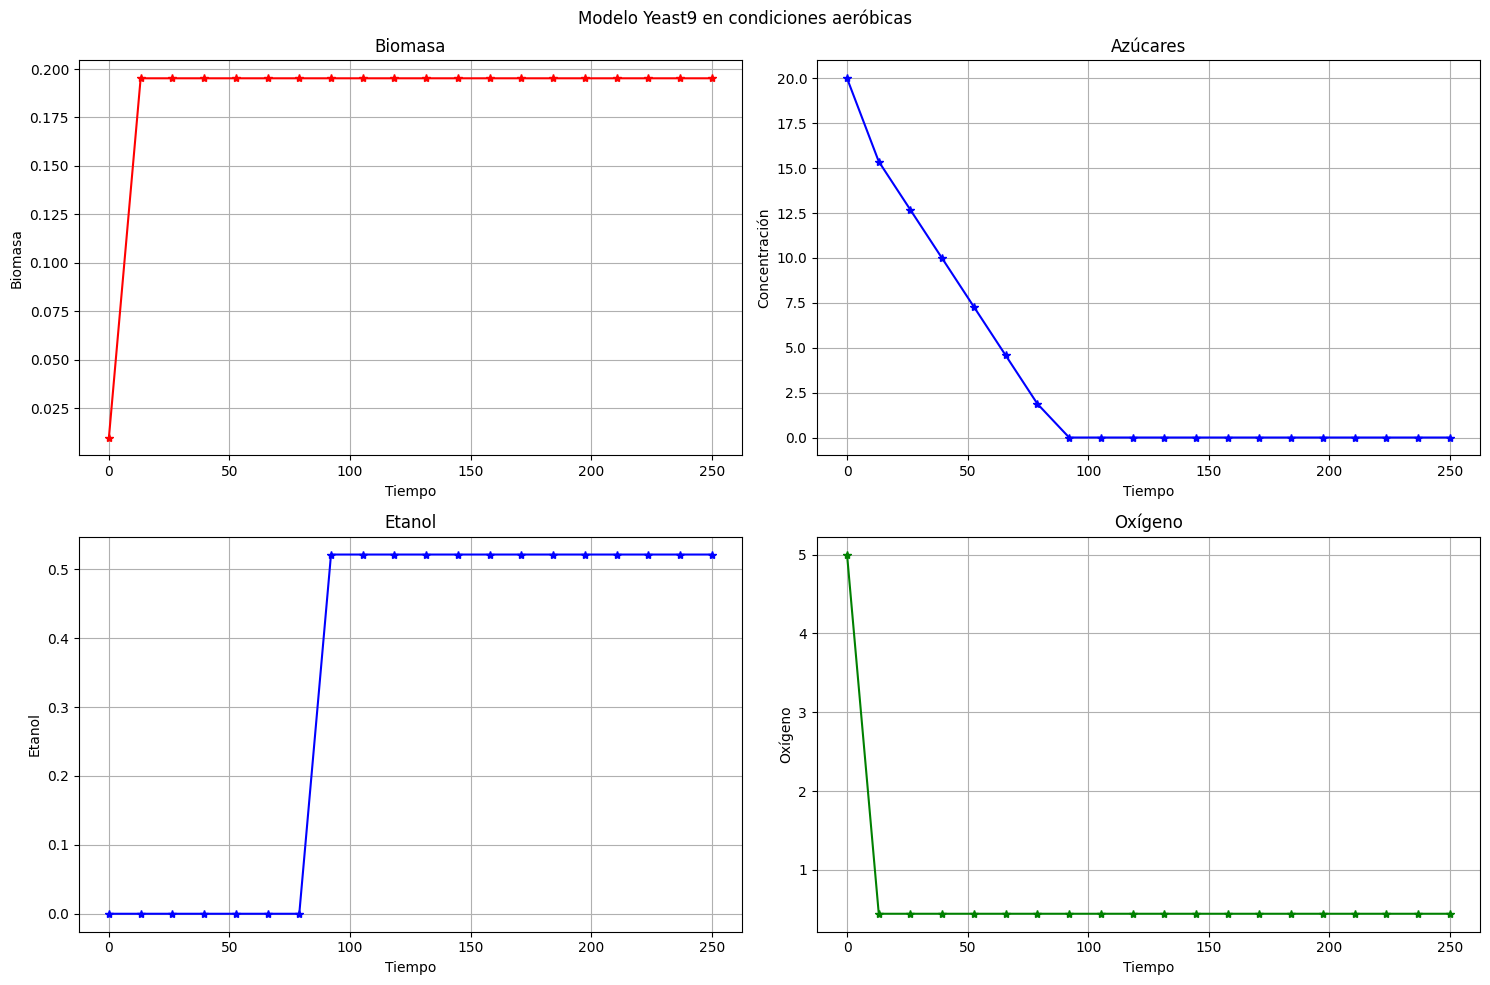

In [35]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

axes[0,0].plot(sol1.t, sol1.y[0], '*-r')
axes[0,0].set_xlabel('Tiempo')
axes[0,0].set_ylabel('Biomasa')
axes[0,0].set_title('Biomasa')
axes[0,0].grid(True)

axes[0,1].plot(sol1.t, sol1.y[51], '*-b')
axes[0,1].set_xlabel('Tiempo')
axes[0,1].set_ylabel('Concentración')
axes[0,1].set_title('Azúcares')
axes[0,1].grid(True)

axes[1,0].plot(sol1.t, sol1.y[60], '*-b')
axes[1,0].set_xlabel('Tiempo')
axes[1,0].set_ylabel('Etanol')
axes[1,0].set_title('Etanol')
axes[1,0].grid(True)

axes[1,1].plot(sol1.t, sol1.y[122], '*-g')
axes[1,1].set_xlabel('Tiempo')
axes[1,1].set_ylabel('Oxígeno')
axes[1,1].set_title('Oxígeno')
axes[1,1].grid(True)

fig.suptitle("Modelo Yeast9 en condiciones aeróbicas")
fig.tight_layout()

### dFBA con modelo original y $O_2$ = 0

In [29]:
init2 = np.zeros(272)
init2[0] = 0.01 # biomasa
init2[38] = 100 # nitrógeno
init2[47] = 100 # fructosa
init2[51] = 20 # glucosa
init2[122] = 0 # oxígeno

model_original_anaerobic.reactions.get_by_id("r_1992").lower_bound = 0.0

print(f"lower bound glucosa {model_original_anaerobic.exchanges.get_by_id('r_1714').lower_bound}")
print(f"lower bound fructosa {model_original_anaerobic.exchanges.get_by_id('r_1709').lower_bound}")

lower bound glucosa -1.0
lower bound fructosa 0.0


In [30]:
# ["r_1757","r_1915","r_1994","r_2106","r_2134","r_2137","r_2189"]
for factores_anaerobicos in ["r_1757","r_1915","r_1994","r_2106","r_2134","r_2137","r_2189"]:
    if factores_anaerobicos in model_original_anaerobic.reactions:
        model_original_anaerobic.reactions.get_by_id(factores_anaerobicos).lower_bound = -1000

Abrimos factores anaeróbicos para estudiar el comportamiento:

- Con todos se tarda mucho.
- Con los 2 del medio no crece

Quitando el cambio 4 crece!

In [31]:
sol2 = dFBA(model_original_anaerobic, int(50), int(121), init2, t_span = (0, 250), t_eval = np.linspace(0, 250, 20),params = (10, 1))

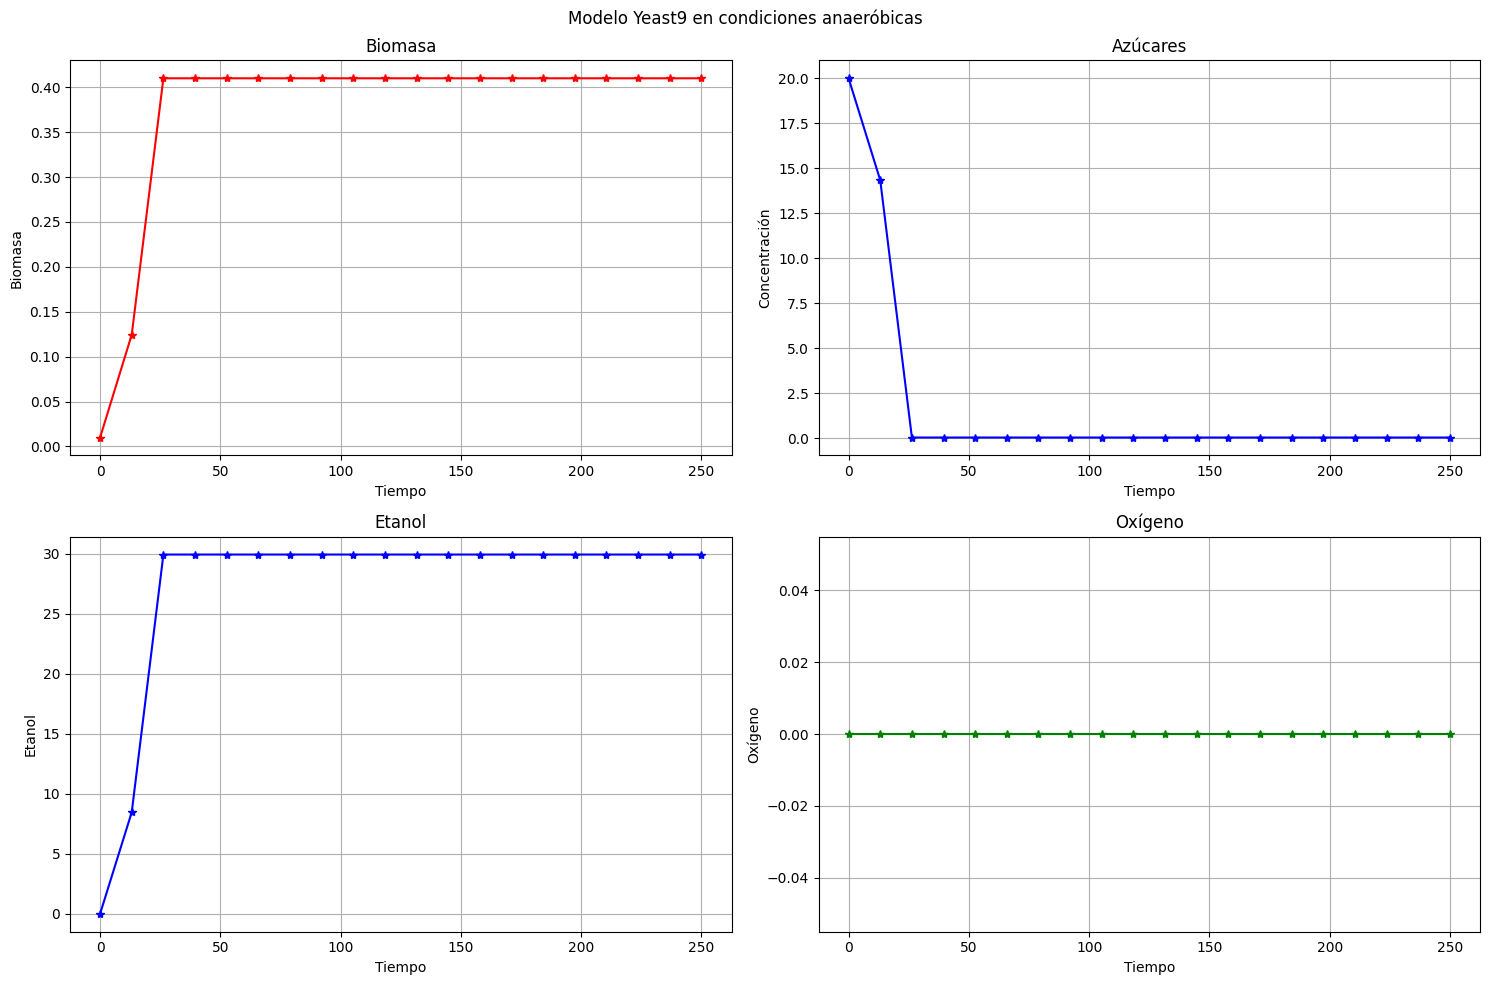

In [36]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

axes[0,0].plot(sol2.t, sol2.y[0], '*-r')
axes[0,0].set_xlabel('Tiempo')
axes[0,0].set_ylabel('Biomasa')
axes[0,0].set_title('Biomasa')
axes[0,0].grid(True)

axes[0,1].plot(sol2.t, sol2.y[51], '*-b')
axes[0,1].set_xlabel('Tiempo')
axes[0,1].set_ylabel('Concentración')
axes[0,1].set_title('Azúcares')
axes[0,1].grid(True)

axes[1,0].plot(sol2.t, sol2.y[60], '*-b')
axes[1,0].set_xlabel('Tiempo')
axes[1,0].set_ylabel('Etanol')
axes[1,0].set_title('Etanol')
axes[1,0].grid(True)

axes[1,1].plot(sol2.t, sol2.y[122], '*-g')
axes[1,1].set_xlabel('Tiempo')
axes[1,1].set_ylabel('Oxígeno')
axes[1,1].set_title('Oxígeno')
axes[1,1].grid(True)

fig.suptitle("Modelo Yeast9 en condiciones anaeróbicas")
fig.tight_layout()

Creo que para que funcione de manera anaeróbica, se debe dejar el lower bound como "abierto" (lo dejé en -1), y que la concentración inicial de la ODE sea 0. 

### dFBA con medio enológico

In [85]:
medio_enologico = [
    # "r_1714","r_1709",      # CARBONO: D-glucose, D-fructose
    "r_1687","r_1552",      # ÁCIDOS ORGÁNICOS: citrate, (S)-malate
    "r_2005","r_2060",      # SALES/IONES: phosphate, sulphate
    "r_2020","r_2049",      # potassium, sodium 
    "r_4593","r_4600",      # chloride, Ca2+
    "r_4597","r_4595",      # Mg2+, Mn2+
    "r_4596","r_4594",      # Zn2+, Cu2+
    "r_1947","r_1967",      # VITAMINAS: myo-inositol, nicotinate
    "r_1548","r_2067",      # (R)-pantothenate, thiamine(1+)
    "r_2028","r_1671",      # pyridoxine, biotin
    "r_1757","r_2189",      # FACTORES ANAERÓBICOS: ergosterol, oleate
    "r_1654",               # ammonium
    # r_1757","r_1915","r_1994","r_2106","r_2134","r_2137","r_2189
    # "r_1915",               # OTROS FACTORES ANAERÓBICOS: lanosterol,
    # "r_1994",               # palmitoleate
    # "r_2106","r_2134",      # zymosterol, 14-demethyllanosterol
    # "r_2137",               # ergosta-5,7,22,24(28)-tetraen-3beta-ol
    "r_1873","r_1879",      # AMINOÁCIDOS: alanine, arginine
    "r_1881","r_1889",      # aspartate, glutamate
    "r_1891","r_1893",      # glutamine, histidine
    "r_1897","r_1899",      # isoleucine, leucine
    "r_1900","r_1902",      # lysine, methionine
    "r_1903","r_1906",      # phenylalanine, proline
    "r_1911","r_1912",      # threonine, tryptophan
    "r_1913","r_1914",      # tyrosine, valine
    "r_1810",               # glycine
    # EXTRAS PARA QUE FUNCIONE MODELO:
    "r_1832",               # H+
    "r_1861",               # iron(2+)
    "r_2100"                # water
]

In [86]:
# Cerramos todos los lower bounds de las reacciones de exchange
for rxn in model_modificado_anaerobic.exchanges:
    rxn.lower_bound = 0
        
# Revisamos que se hayan cerrado correctamente con el intercambio de amonio:
print(f"Antes {model_modificado_anaerobic.exchanges.get_by_id('r_1654').name} (límite: {model_modificado_anaerobic.exchanges.get_by_id('r_1654').lower_bound})")
for reaction in medio_enologico:
    model_modificado_anaerobic.exchanges.get_by_id(reaction).lower_bound = -1000
print(f"Después {model_modificado_anaerobic.exchanges.get_by_id('r_1654').name} (límite: {model_modificado_anaerobic.exchanges.get_by_id('r_1654').lower_bound})")

# agregamos manualmente glucosa y fructosa
model_modificado_anaerobic.exchanges.get_by_id('r_1714').lower_bound = -1.0
model_modificado_anaerobic.exchanges.get_by_id('r_1709').lower_bound = -1.0
    
# Asegurar anaerobiosis:
model_modificado_anaerobic.reactions.get_by_id("r_1992").lower_bound = 0.0 # consumo de oxígeno a 0

Antes ammonium exchange (límite: 0)
Después ammonium exchange (límite: -1000)


Correr el modelo anaeróbico con medio enológico:
- Tarda una hora en correr y dio 0 (con todos los factores anaeróbicos).
- Con 2 factores enológico, no crece.

Quitando el 4to cambio para el modelo anaeróbico: 
- Tarda con todos los factores anaeróbicos.
- Dejando los del medio enológico no crece.
- Probando dejando solo ergosterol, oleate, lanosterol, palmitoleate se queda pegado corriendo.
- Probando dejando solo ergosterol, oleato, zymosterol, 14-demethyllanosterol no crece.
- Probando dejando solo ergosterol, oleate, lanosterol no crece.
- Probando dejando solo ergosterol, oleate, palmitoleate 


Uno de las cosas que se abre en el medio enológico provoca que no crezca.

In [87]:
sol3 = dFBA(model_modificado_anaerobic, int(50), int(121), init2, t_span = (0, 250), t_eval = np.linspace(0, 250, 10),params = (10, 1))

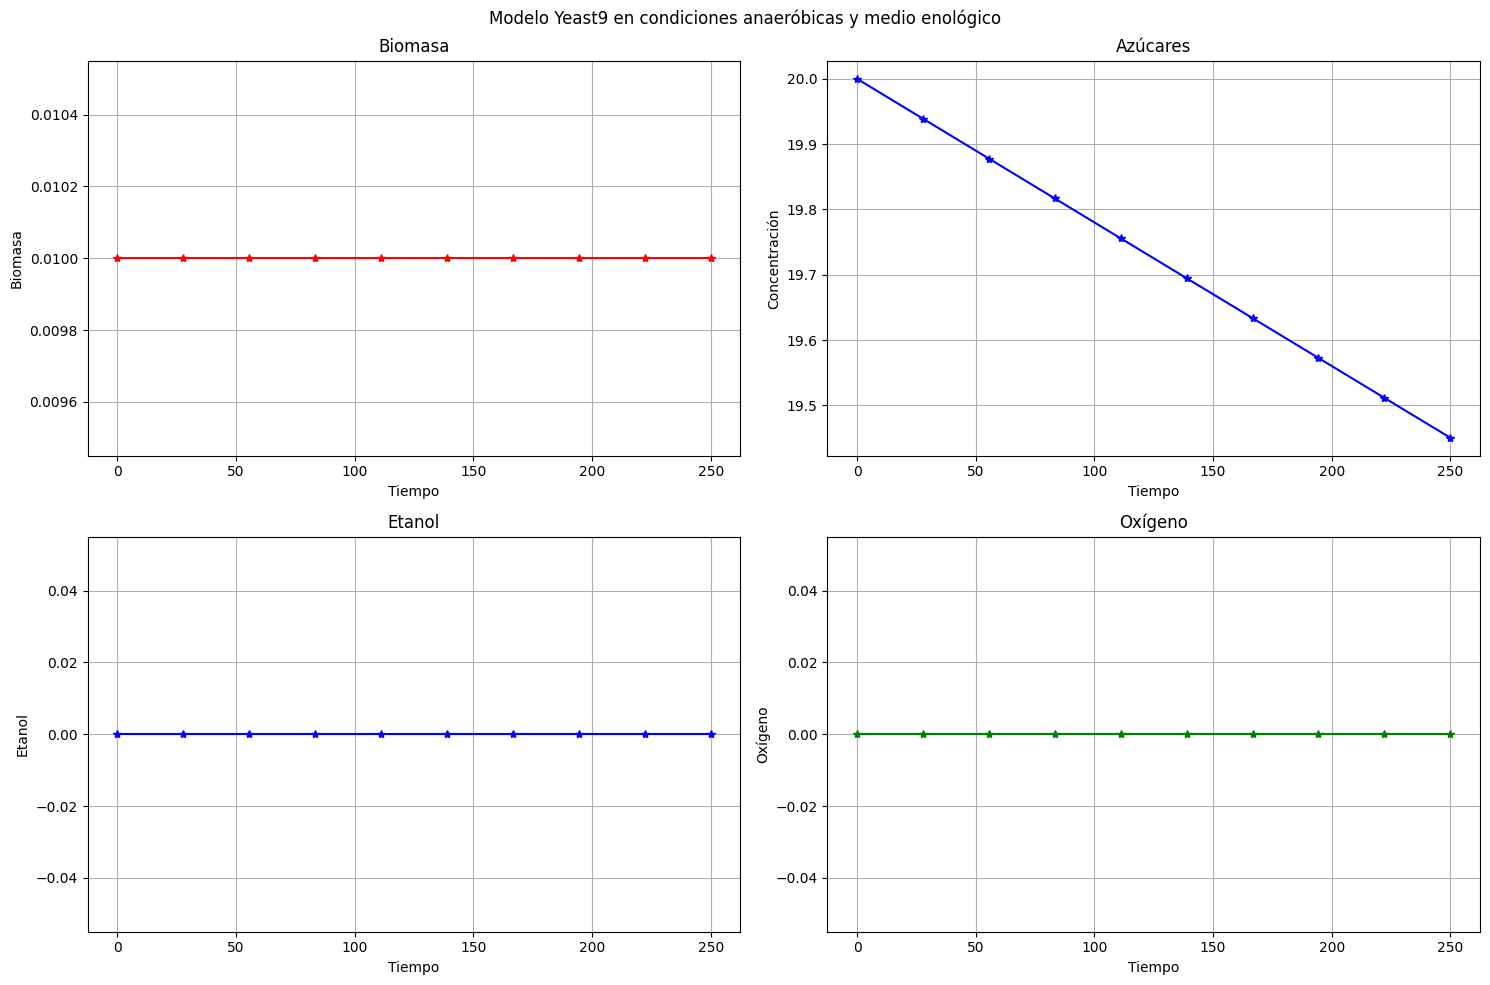

In [88]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

axes[0,0].plot(sol3.t, sol3.y[0], '*-r')
axes[0,0].set_xlabel('Tiempo')
axes[0,0].set_ylabel('Biomasa')
axes[0,0].set_title('Biomasa')
axes[0,0].grid(True)

axes[0,1].plot(sol3.t, sol3.y[51], '*-b')
axes[0,1].set_xlabel('Tiempo')
axes[0,1].set_ylabel('Concentración')
axes[0,1].set_title('Azúcares')
axes[0,1].grid(True)

axes[1,0].plot(sol3.t, sol3.y[60], '*-b')
axes[1,0].set_xlabel('Tiempo')
axes[1,0].set_ylabel('Etanol')
axes[1,0].set_title('Etanol')
axes[1,0].grid(True)

axes[1,1].plot(sol3.t, sol3.y[122], '*-g')
axes[1,1].set_xlabel('Tiempo')
axes[1,1].set_ylabel('Oxígeno')
axes[1,1].set_title('Oxígeno')
axes[1,1].grid(True)

fig.suptitle("Modelo Yeast9 en condiciones anaeróbicas y medio enológico")
fig.tight_layout()

### Gráficos:

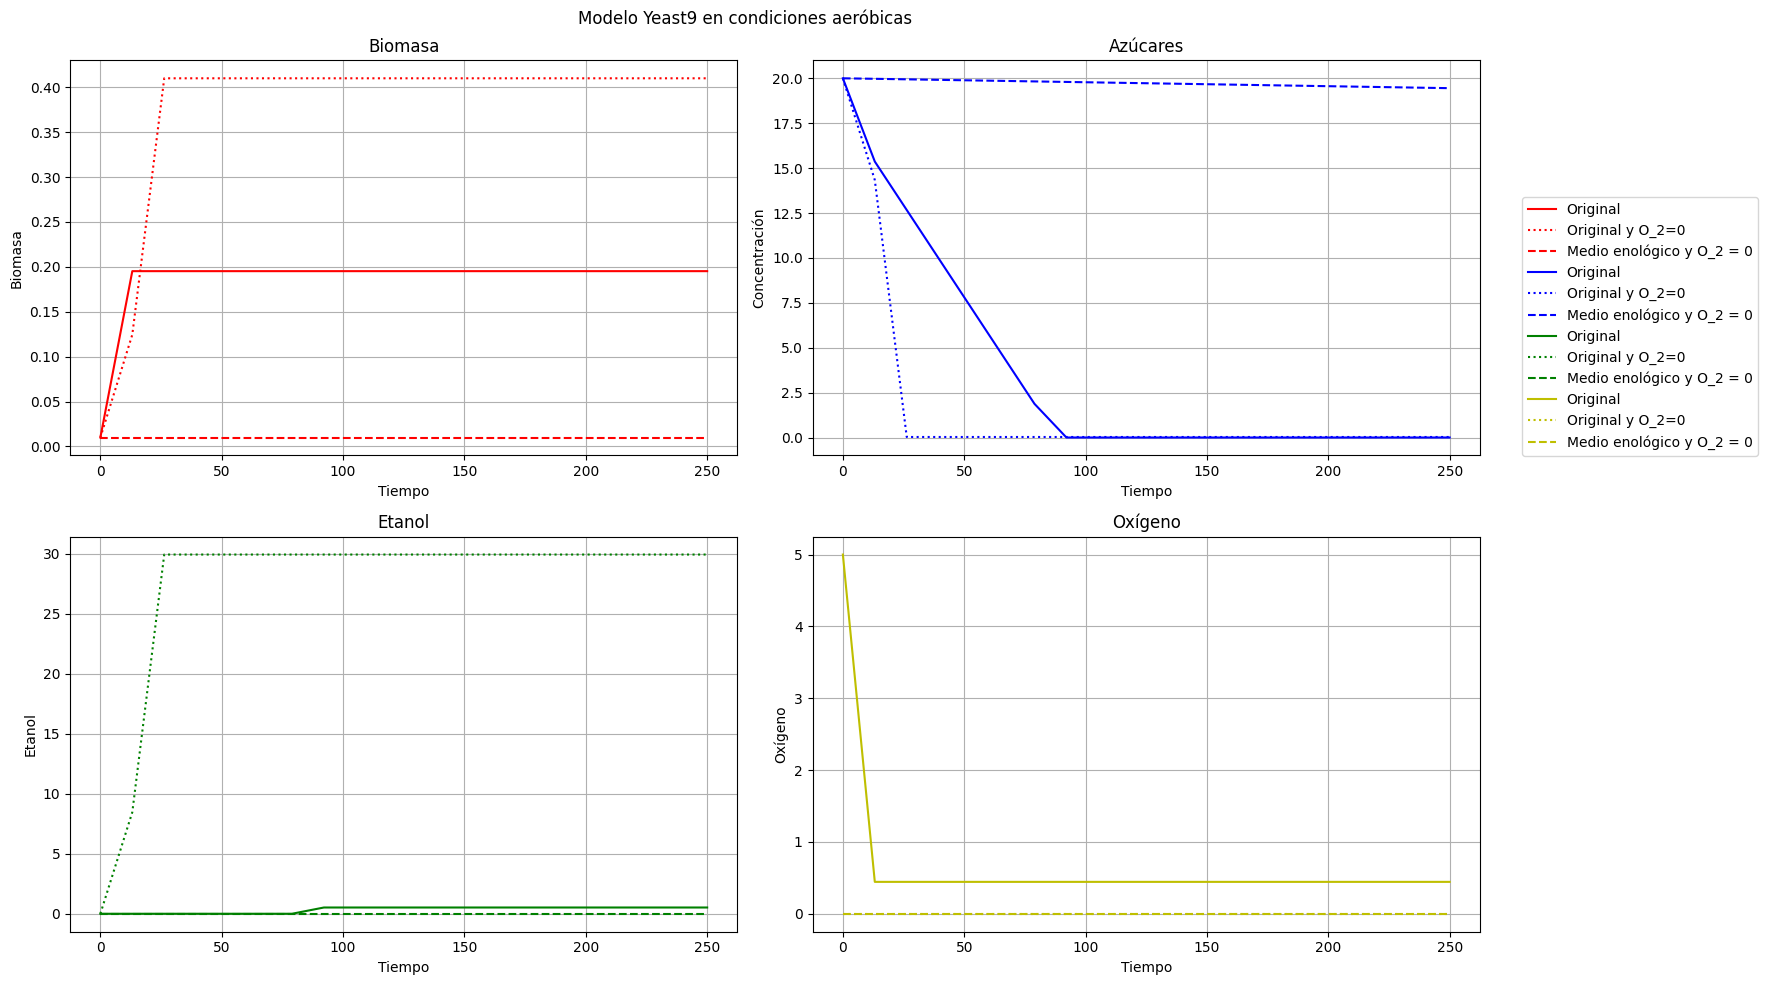

In [89]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

axes[0,0].plot(sol1.t, sol1.y[0], '-r', label="Original")
axes[0,0].plot(sol2.t, sol2.y[0], ':r', label = "Original y O_2=0")
axes[0,0].plot(sol3.t, sol3.y[0], '--r', label = "Medio enológico y O_2 = 0")
axes[0,0].set_xlabel('Tiempo')
axes[0,0].set_ylabel('Biomasa')
axes[0,0].set_title('Biomasa')
axes[0,0].grid(True)

# axes[0,1].plot(sol1.t, sol1.y[51], '*-b')
axes[0,1].plot(sol1.t, sol1.y[51], '-b', label="Original")
axes[0,1].plot(sol2.t, sol2.y[51], ':b', label = "Original y O_2=0")
axes[0,1].plot(sol3.t, sol3.y[51], '--b', label = "Medio enológico y O_2 = 0")
axes[0,1].set_xlabel('Tiempo')
axes[0,1].set_ylabel('Concentración')
axes[0,1].set_title('Azúcares')
axes[0,1].grid(True)

#axes[1,0].plot(sol1.t, sol1.y[60], '*-b')
axes[1,0].plot(sol1.t, sol1.y[60], '-g', label="Original")
axes[1,0].plot(sol2.t, sol2.y[60], ':g', label = "Original y O_2=0")
axes[1,0].plot(sol3.t, sol3.y[60], '--g', label = "Medio enológico y O_2 = 0")
axes[1,0].set_xlabel('Tiempo')
axes[1,0].set_ylabel('Etanol')
axes[1,0].set_title('Etanol')
axes[1,0].grid(True)

# axes[1,1].plot(sol1.t, sol1.y[122], '*-g')
axes[1,1].plot(sol1.t, sol1.y[122], '-y', label="Original")
axes[1,1].plot(sol2.t, sol2.y[122], ':y', label = "Original y O_2=0")
axes[1,1].plot(sol3.t, sol3.y[122], '--y', label = "Medio enológico y O_2 = 0")
axes[1,1].set_xlabel('Tiempo')
axes[1,1].set_ylabel('Oxígeno')
axes[1,1].set_title('Oxígeno')
axes[1,1].grid(True)

fig.legend(bbox_to_anchor=(1.18, 0.8))

fig.suptitle("Modelo Yeast9 en condiciones aeróbicas")
fig.tight_layout()